In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astroquery.gaia import Gaia
import pandas as pd
from sn_tools.sn_io import checkDir

In [2]:
# Need to create an account to access all data
Gaia.login()

INFO: Login to gaia TAP server [astroquery.gaia.core]


User:  pgris
Password:  ········


INFO: OK [astroquery.utils.tap.core]
INFO: Login to gaia data server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]


# get Gaia data

In [9]:
def get_gaia_single(source_id,gaiadr='gaiadr3'):
    vars = 'source_id, ra, dec, pmra, pmdec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, l, b, phot_variable_flag, ref_epoch'
    vars += ', L, B, visibility_periods_used, phot_bp_mean_flux_over_error, phot_rp_mean_flux_over_error, phot_g_mean_flux_over_error, phot_bp_rp_excess_factor'
    vars += ' , astrometric_chi2_al, astrometric_n_good_obs_al'
    
    if gaiadr == 'gaiadr2':
        vars += ', a_g_val'
    if gaiadr == 'gaiadr3':
        vars += ', ag_gspphot'

    query = "SELECT {} \
    FROM {}.gaia_source \
    WHERE source_id={}".format(vars,gaiadr,source_id)

    job     = Gaia.launch_job_async(query,verbose=True)
    #job     = Gaia.launch_job(query)
    results = job.get_results()
    print(f'Table size (rows): {len(results)}')
    results
    return results.to_pandas()


In [10]:
def get_gaia_from_db(ra_min,ra_max,gaiadr='gaiadr2',catname='gaia_source'):
    # Main query, get selected infos with criteria.
    # All data information are given in the Gaia data model: 
    # https://gea.esac.esa.int/archive/documentation/GDR3/Gaia_archive/chap_datamodel/sec_dm_main_source_catalogue/ssec_dm_gaia_source.html

    vars = 'source_id, ra, dec, pmra, pmdec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, l, b, phot_variable_flag, ref_epoch'
    vars += ', L, B'
    
    if gaiadr == 'gaiadr2':
        vars += ', a_g_val'
    if gaiadr == 'gaiadr3':
        vars += ', ag_gspphot'

    """
    query = "SELECT {} \
    FROM {}.gaia_source \
    WHERE visibility_periods_used > 5 \
    AND astrometric_excess_noise < 0.5 \
    AND parallax > 1 \
    AND parallax_over_error > 5 \
    AND phot_bp_mean_flux_over_error > 20 \
    AND phot_rp_mean_flux_over_error > 20 \
    AND phot_g_mean_flux_over_error > 50 \
    AND phot_bp_rp_excess_factor < 1.2*(1.2+0.03*power(phot_bp_mean_mag-phot_rp_mean_mag,2)) \
    AND ra >= {} \
    and ra < {}".format(vars,gaiadr,ra_min,ra_max)
    """
    query = "SELECT {} \
    FROM {}.{} \
    WHERE visibility_periods_used > 8 \
    AND parallax_over_error > 10 \
    AND phot_bp_mean_flux_over_error > 20 \
    AND phot_rp_mean_flux_over_error > 20 \
    AND phot_g_mean_flux_over_error > 50 \
    AND phot_bp_rp_excess_factor < 1.3+0.06*power(phot_bp_mean_mag-phot_rp_mean_mag,2) \
    AND phot_bp_rp_excess_factor > 1.0+0.015*power(phot_bp_mean_mag-phot_rp_mean_mag,2) \
    AND astrometric_chi2_al/(astrometric_n_good_obs_al-5) < 1.44*greatest(1,exp(-0.4*(phot_g_mean_mag-19.5))) \
    AND ra >= {} \
    and ra < {}".format(vars,gaiadr,catname,ra_min,ra_max)    
    
    print(query)
    job     = Gaia.launch_job_async(query,verbose=True)
    #job     = Gaia.launch_job(query)
    results = job.get_results()
    print(f'Table size (rows): {len(results)}')
    results
    return results.to_pandas()


In [11]:
def get_gaia_variable(gaiadr='gaiadr2',table='vari_cepheid'):
    
    vars = 'source_id'
        
    query = 'SELECT {} FROM {}.{}'.format(vars,gaiadr,table)
    print(query)
    job     = Gaia.launch_job_async(query,verbose=True)
    #job     = Gaia.launch_job(query)
    results = job.get_results()
    print(f'Table size (rows): {len(results)}')
    results
    return results.to_pandas()

In [12]:
def get_gaia_from_dr(ra_min,ra_max,gaiadr='gaiadr2',catname='gaia_source'):
    
    tt = get_gaia_from_db(ra_min, ra_max,gaiadr,catname)
    ag = 'a_g_val'
    if gaiadr == 'gaiadr3':
        ag = 'ag_gspphot'
    # absolute mag G band - see Gaia Data Release 2 Documentation
    tt['MG'] = tt['phot_g_mean_mag']+5-5*np.log10(1.e3/tt['parallax'])-tt[ag]
    return tt

In [13]:
def get_gaia_data(ra_min,ra_max,catname,drs=['gaiadr3']):
    
    df = pd.DataFrame()

    for dr in drs:
        dfa = get_gaia_from_dr(ra_min,ra_max,dr,catname)
        dfa['gaiadr'] = dr
        df = pd.concat((df,dfa))

    return df

In [16]:
#Gaia.login()
drs = 'gaiadr3'
catname = 'astrophysical_parameters'
ramin = 0
ramax = 360
delta_ra = 6
ras = np.arange(ramin,ramax,delta_ra)
outDir = '/home/philippe/LSST/gaia_files/{}'.format(drs)
checkDir(outDir)
for ra in ras:
    ra_min = np.round(ra,1)
    ra_max = np.round(ra_min+delta_ra,1)
    print(ra_min,ra_max)
    df = get_gaia_data(ra_min,ra_max,catname,[drs])
    out_name = '{}/cat_gaia_{}_{}_{}.hdf5'.format(gaia_catalog,drs,ra_min,ra_max)
    df.to_hdf(out_name,key='star')

0 6
SELECT source_id, ra, dec, pmra, pmdec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, l, b, phot_variable_flag, ref_epoch, L, B, ag_gspphot     FROM gaiadr3.astrophysical_parameters     WHERE visibility_periods_used > 8     AND parallax_over_error > 10     AND phot_bp_mean_flux_over_error > 20     AND phot_rp_mean_flux_over_error > 20     AND phot_g_mean_flux_over_error > 50     AND phot_bp_rp_excess_factor < 1.3+0.06*power(phot_bp_mean_mag-phot_rp_mean_mag,2)     AND phot_bp_rp_excess_factor > 1.0+0.015*power(phot_bp_mean_mag-phot_rp_mean_mag,2)     AND astrometric_chi2_al/(astrometric_n_good_obs_al-5) < 1.44*greatest(1,exp(-0.4*(phot_g_mean_mag-19.5)))     AND ra >= 0     and ra < 6
Launched query: 'SELECT source_id, ra, dec, pmra, pmdec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, l, b, phot_variable_flag, ref_epoch, L, B, ag_gspphot     FROM gaiadr3.astrophysical_parameters     WHERE visibility_periods_used > 8

HTTPError: Error 500:
null

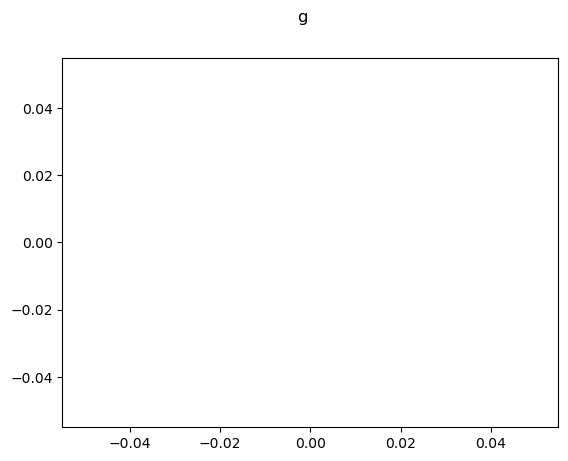

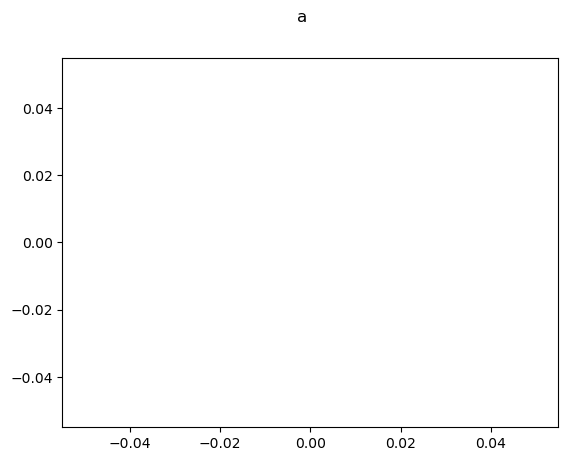

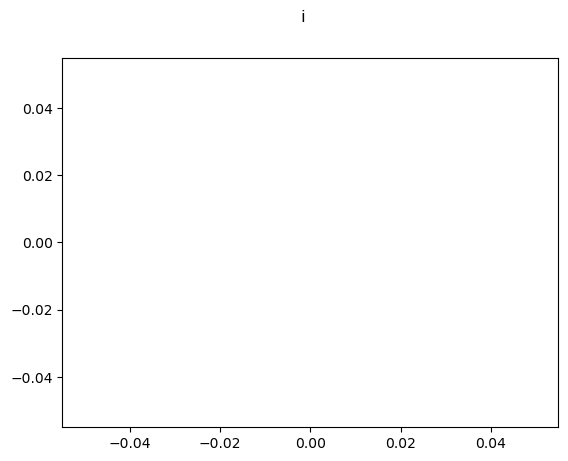

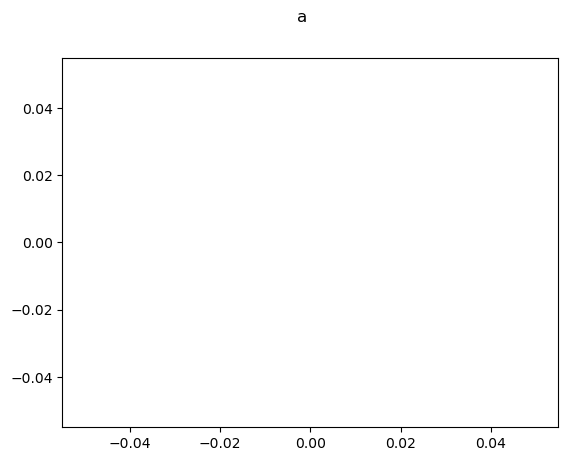

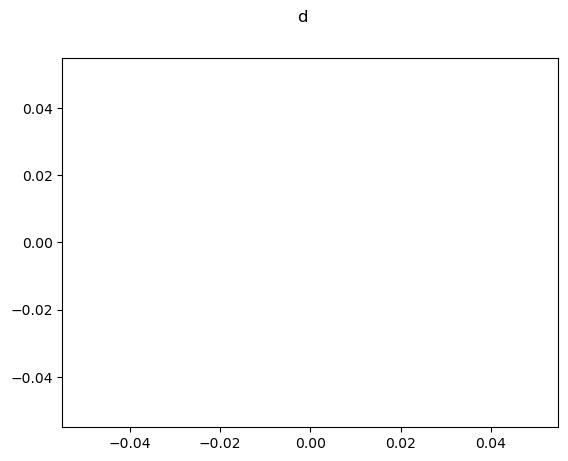

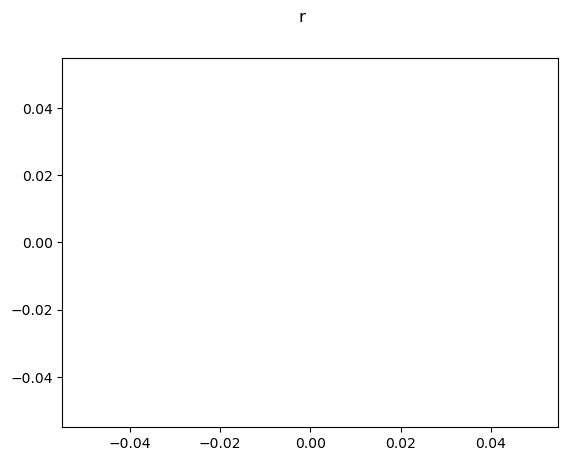

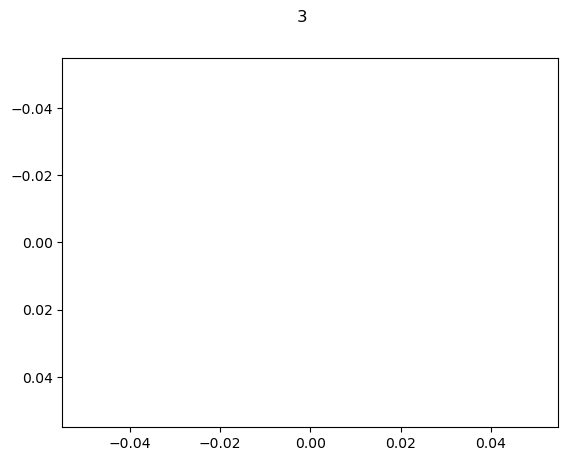

In [21]:

for dr in drs:
    fig, ax = plt.subplots()
    fig.suptitle(dr)
    idx = df['gaiadr'] == dr
    tt = df[idx]
    ax.plot(tt['phot_bp_mean_mag']-tt['phot_rp_mean_mag'],tt['MG'],'k.',ms=0.05)
plt.gca().invert_yaxis()

In [51]:
def check_sel(df):

    df['parallax_over_error'] = df['parallax']/df['parallax_error']
    df['var_test'] = np.exp(-0.4*(df['phot_g_mean_mag']-19.5))
    print(df['var_test'])
    idx = df['visibility_periods_used'] > 8
    print('1',len(df[idx]))
    idx = df['parallax_over_error'] > 10
    print('2',len(df[idx]))
    idx =  df['phot_bp_mean_flux_over_error'] > 20
    print('3',len(df[idx]))
    idx = df['phot_rp_mean_flux_over_error'] > 20
    print('4',len(df[idx]))
    idx = df['phot_g_mean_flux_over_error'] > 50
    print('5',len(df[idx]))
    idx = df['phot_bp_rp_excess_factor'] < 1.3+0.06*(df['phot_bp_mean_mag']-df['phot_rp_mean_mag'])**2
    print('6',len(df[idx]))
    idx = df['phot_bp_rp_excess_factor'] > 1.0+0.015*(df['phot_bp_mean_mag']-df['phot_rp_mean_mag'])**2
    print('7',len(df[idx]))
    vv = np.array([1,df['var_test'].to_list()[0]])
    print(vv)
    idx = df['astrometric_chi2_al']/(df['astrometric_n_good_obs_al']-5) < 1.44*np.max(vv)
    print('8',len(df[idx]))
    

In [56]:
dd = get_gaia_single(5493730399606077440)
ddb = get_gaia_single(2901155648586891776)
ddb = get_gaia_single(2901155648586891648)

Launched query: 'SELECT source_id, ra, dec, pmra, pmdec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, l, b, phot_variable_flag, ref_epoch, L, B, visibility_periods_used, phot_bp_mean_flux_over_error, phot_rp_mean_flux_over_error, phot_g_mean_flux_over_error, phot_bp_rp_excess_factor , astrometric_chi2_al, astrometric_n_good_obs_al, ag_gspphot     FROM gaiadr3.gaia_source     WHERE source_id=5493730399606077440'
------>https
host = gea.esac.esa.int:443
context = /tap-server/tap/async
Content-type = application/x-www-form-urlencoded
303 303
[('Date', 'Wed, 03 Jul 2024 10:20:38 GMT'), ('Server', 'Apache/2.4.6 (CentOS) OpenSSL/1.0.2k-fips mod_jk/1.2.43'), ('Cache-Control', 'no-cache, no-store, max-age=0, must-revalidate'), ('Pragma', 'no-cache'), ('Expires', '0'), ('X-XSS-Protection', '1; mode=block'), ('X-Frame-Options', 'SAMEORIGIN'), ('X-Content-Type-Options', 'nosniff'), ('Set-Cookie', 'JSESSIONID=C2982CA1A3B4D0FB2DB651EF7851F3B8; Path=/tap-server; Sec

In [57]:
vvars = ['phot_bp_mean_flux_over_error','phot_rp_mean_flux_over_error','phot_g_mean_flux_over_error','visibility_periods_used']
dd[vvars]

check_sel(dd)
check_sel(ddb)

0    170.272598
Name: var_test, dtype: float32
1 1
2 1
3 1
4 1
5 1
6 1
7 1
[  1.         170.27259827]
8 1
0    316.564606
Name: var_test, dtype: float32
1 1
2 1
3 1
4 1
5 1
6 1
7 1
[  1.         316.56460571]
8 1


In [5]:
# get variables here
for table in ['vari_cepheid','vari_long_period_variable','vari_rotation_modulation',
              'vari_rrlyrae','vari_short_timescale','vari_time_series_statistics']:
    res = get_gaia_variable('gaiadr2',table=table)
    res.to_hdf('{}.hdf5'.format(table),key='variable')



SELECT source_id FROM gaiadr2.vari_cepheid
Launched query: 'SELECT source_id FROM gaiadr2.vari_cepheid'
------>https
host = gea.esac.esa.int:443
context = /tap-server/tap/async
Content-type = application/x-www-form-urlencoded
303 303
[('Date', 'Mon, 29 Jul 2024 13:26:21 GMT'), ('Server', 'Apache/2.4.6 (CentOS) OpenSSL/1.0.2k-fips mod_jk/1.2.43'), ('Cache-Control', 'no-cache, no-store, max-age=0, must-revalidate'), ('Pragma', 'no-cache'), ('Expires', '0'), ('X-XSS-Protection', '1; mode=block'), ('X-Frame-Options', 'SAMEORIGIN'), ('X-Content-Type-Options', 'nosniff'), ('Set-Cookie', 'JSESSIONID=8DFA8DA4ED9B24A97CDFAED1C6C94CC3; Path=/tap-server; Secure; HttpOnly'), ('Location', 'https://gea.esac.esa.int/tap-server/tap/async/1722259581348O'), ('Transfer-Encoding', 'chunked'), ('Content-Type', 'text/plain;charset=ISO-8859-1')]
job 1722259581348O, at: https://gea.esac.esa.int/tap-server/tap/async/1722259581348O
Retrieving async. results...
INFO: Query finished. [astroquery.utils.tap.core]
T

In [6]:
def get_gaia_oba_golden():

    query = 'SELECT * from gaiadr3.gold_sample_oba_stars'
    job     = Gaia.launch_job_async(query)
    #job     = Gaia.launch_job(query)
    results = job.get_results()
    print(f'Table size (rows): {len(results)}')
    results
    return results.to_pandas()

    

In [7]:
res = get_gaia_oba_golden()
print(res)

500 Error 500:
null


HTTPError: Error 500:
null